# Cookie Cats A/B Test: Retention vs Monetization

This notebook presents the code written to perform the A/B testing analysis for the cookie cats game dataset, and exposes two different lenses for which to view the outcomes: retention and monetization.
As specified in the dataset information we have, for each user, the group it belongs to (version with gate at level 30 vs level 40), its retention (within the first and the first seven days of playing the game) and the total gamerounds it has initiated.

In [ ]:
import numpy as np
import pandas as pd
#Viz
import matplotlib.pyplot as plt
# Stats
from scipy.stats import chisquare, norm, binomtest
from statsmodels.stats.proportion import proportions_ztest

In [31]:
# Load the data
data = pd.read_csv('datasets/cookie_cats.csv')

## O. Data Preprocessing
### 0.1 Naming Conventions and Data Types

In [ ]:
# Standardize column names to lowercase
data.columns = data.columns.str.lower()

# Convert retention columns to integers
for col in ['retention_1', 'retention_7']:
    data[col] = data[col].astype(int)

### 0.2 Removing Outliers

In [ ]:

# Perform log transformation and IQR filtering on sum_gamerounds to mitigate the effect of outliers
log_col = np.log1p(data[sum_gamerounds])
q1 = log_col.quantile(0.25)
q3 = log_col.quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
mask = (log_col >= lower) & (log_col <= upper)
print(f"Rows before: {data.shape[0]}, after log-IQR filter: {mask.sum()} (removed: {data.shape[0] - mask.sum()})")
data = data[mask].copy()

Rows before: 90189, after log-IQR filter: 90148 (removed: 41)


### 0.3 Quick Checks

In [ ]:
# Check for nulls and duplicates
null_counts = data.isnull().sum()
print("Any nulls in dataset?:", null_counts.any())

dup_mask = data['userid'].duplicated(keep=False)
dup_any = dup_mask.any()
print(f"\nAny duplicate userids?: {dup_any}")

Any nulls in dataset?: False

Any duplicate userids?: False


## 1. Sample Ratio Mismatch

In [ ]:
# Proportion of users in each version
props = data["version"].value_counts(normalize=True)
print("\nProportion per version:")
print(props)


Proportion per version:
version
gate_40    0.504371
gate_30    0.495629
Name: proportion, dtype: float64


Percentage of users in each group (percentage) looks almost identical, so it appears to be no hints of wrong sampling procedures during the A/B test.
Still, we'll double-check by running a Chi-Square test on the observed frequencies:

In [ ]:
# Perform binomial test to check for SRM in version assignment
observed = data["version"].value_counts().sort_index()
total = observed.sum()
print("Observed unique users per version:")
print(observed.to_string())

level = observed.index[0]
count_level = int(observed.iloc[0])
b = binomtest(count_level, total, p=1/2)
binom_p = b.pvalue
print(f"Binomial test for '{level}' vs 50%: p={binom_p:.4f}")

# Choosing lower alpha to be more conservative given the large sample size
alpha = 0.001
if binom_p < alpha:
    print(f"\nConclusion (alpha={alpha}): evidence of SRM (p={binom_p:.4f} < {alpha})")
else:
    print(f"\nConclusion (alpha={alpha}): no evidence of SRM (p={binom_p:.4f} >= {alpha})")

Observed unique users per version:
version
gate_30    44680
gate_40    45468
Binomial test for 'gate_30' vs 50%: p=0.0088

Conclusion (alpha=0.001): no evidence of SRM (p=0.0088 >= 0.001)


## Primary Metrics and Guardrails

Depending on the business objective, the metrics can swap roles:

- Retention as Primary Metric and game rounds as Guardrail - If the goal is long-term retention, prioritize for 1-day and 7-day retention and use game rounds to make sure the gate placement does not tank playtime. 
- Game rounds as Primary Metric and retention as Guardrail - If the goal is ad revenue from playtime, prioritize for game rounds and use retention to check that short-term engagement spikes do not cause burnout and churn long-term.

## 2. Analysis
### 2.1 Retention

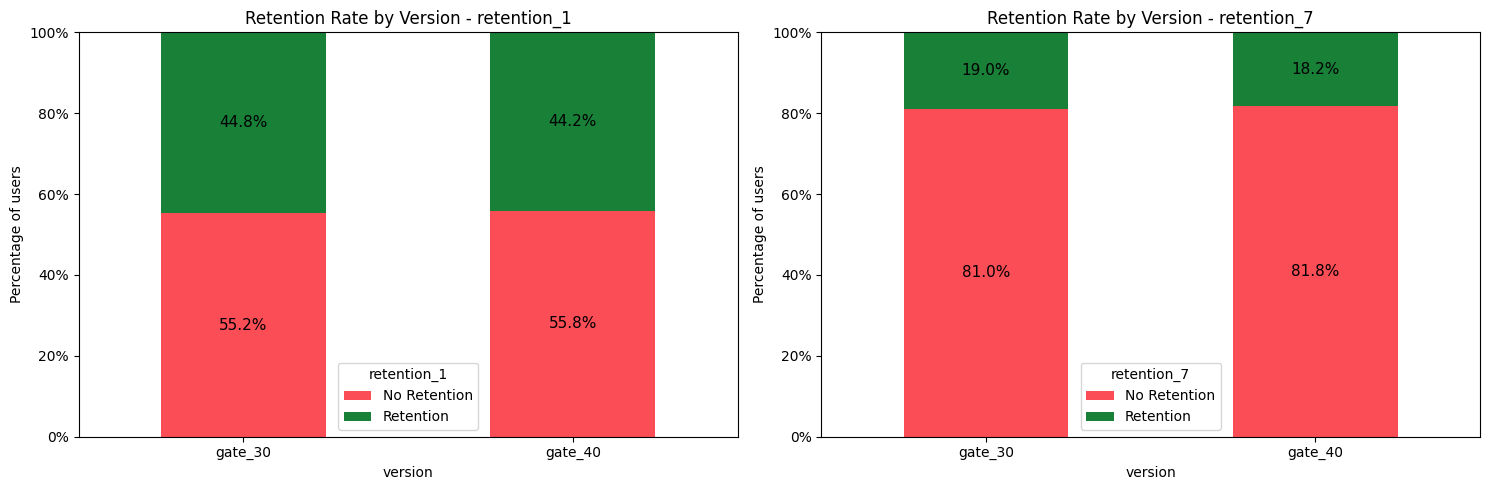

In [ ]:
import numpy as np
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, col in enumerate(["retention_1", "retention_7"]):
    # calculate proportions of retention vs no retention for each version
    proportions = (
        data.groupby("version")[col]
        .value_counts(normalize = True)
        .unstack()
        .rename(columns={0: "No Retention", 1: "Retention"})
    )
    proportions.plot(kind = "bar", stacked = True, ax = axes[i], color = ["#fa4d56", "#198038"])

    # label percentages centered in each bar
    for container in axes[i].containers:
        labels = [f"{v:.1%}" for v in container.datavalues]
        axes[i].bar_label(container, labels = labels, label_type = "center", fontsize = 11)

    axes[i].set_xticks(x)
    axes[i].set_xticklabels(versions, rotation=0)
    axes[i].set_title(f"Retention Rate by Version - {col}")
    axes[i].set_ylim(0, 1)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    axes[i].set_ylabel("Percentage of users")
    axes[i].legend(title = col)

plt.tight_layout()
plt.show()

Noticed trends:
- Retention drops significantly between day 1 and day 7 for both groups. A large proportion of players who return on day 1 are not playing by day 7.
- gate_40 shows slightly lower retention in both timeframes, with the gap being slightly larger at 7 days. We will determine later if this is statistically significant

### 2.2 Game Rounds

In [ ]:
data.groupby("version")[["sum_gamerounds"]].describe()

sum_gamerounds                                                    
                 count       mean        std  min  25%   50%   75%     max
version                                                                   
gate_30        44680.0  50.635497  95.747779  0.0  5.0  17.0  50.0  1324.0
gate_40        45468.0  50.532572  96.707713  0.0  5.0  16.0  52.0  1323.0

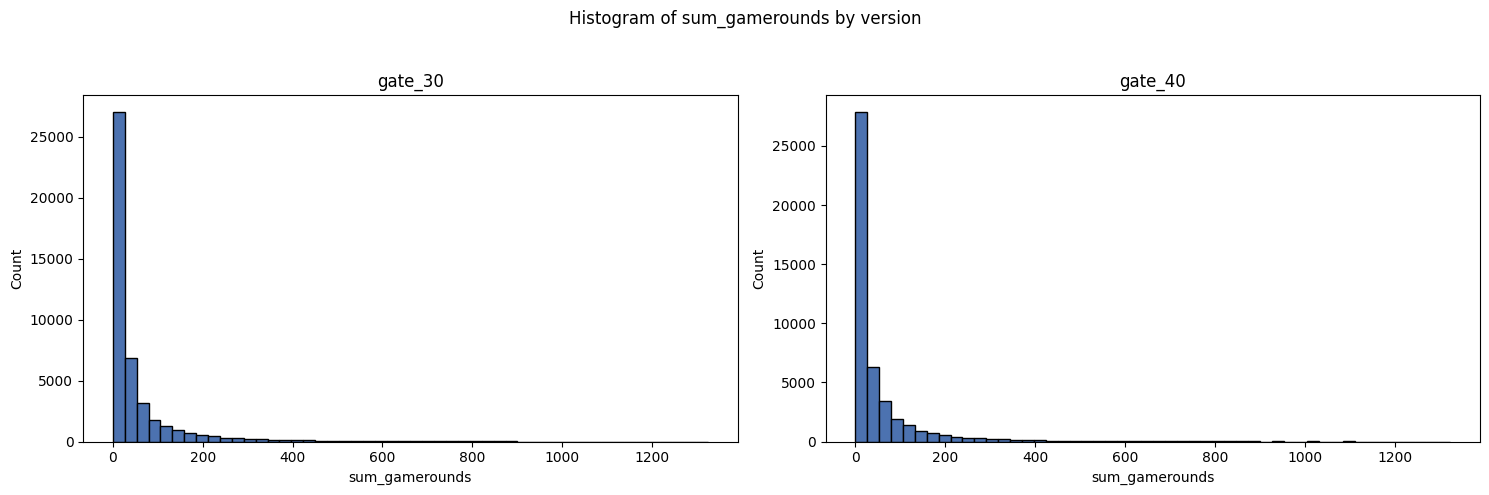

In [ ]:
# Plot histograms of sum_gamerounds for each version
versions = sorted(data["version"].unique())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, v in zip(axes, versions):
    vals = data.loc[data["version"] == v, "sum_gamerounds"]
    ax.hist(vals, bins=50, color="#4C72B0", edgecolor="black")
    ax.set_title(v)
    ax.set_xlabel("sum_gamerounds")
    ax.set_ylabel("Count")

plt.suptitle("Histogram of sum_gamerounds by version")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

The heavy right skew makes the histograms mostly uninformative. Both distributions look visually indistinguishable. The summary statistics tell a similar story: 50 round mean, 102 standard deviation and the quartiles are very similar between gate_30 and gate_40. There does not seem to be a engagement difference by the gate placement.

## 3. Statistical Tests
### 3.1 Retention

In [ ]:
# perform z-test for retention rates between versions
for col in ["retention_1", "retention_7"]:
    groups = data.groupby("version")[col]
    successes = groups.sum().sort_index().values
    totals = groups.count().sort_index().values
    versions = groups.sum().sort_index().index.tolist()

    # z-test (two-sided)
    z_stat, p_value = proportions_ztest(successes, totals)
    props = successes / totals
    diff = props[1] - props[0]

    se = (props[0] * (1 - props[0]) / totals[0] + props[1] * (1 - props[1]) / totals[1]) ** 0.5
    z_crit = norm.ppf(1 - 0.05 / 2)
    ci_low, ci_up = diff - z_crit * se, diff + z_crit * se

    print(f"{col}: versions = {versions}")
    print(f"  counts (successes) = {successes.tolist()}, nobs = {totals.tolist()}")
    print(f"  proportions = {[f'{p:.4f}' for p in props]}, difference (v2 - v1) = {diff:+.4%}")
    print(f"  z = {z_stat:.4f}, p = {p_value:.4f}, 95% CI diff = [{ci_low:+.4%}, {ci_up:+.4%}]\n")

retention_1: versions = ['gate_30', 'gate_40']
  counts (successes) = [20015, 20098], nobs = [44680, 45468]
  proportions = ['0.4480', '0.4420'], difference (v2 - v1) = -0.5938%
  z = 1.7937, p = 0.0729, 95% CI diff = [-1.2427%, +0.0550%]

retention_7: versions = ['gate_30', 'gate_40']
  counts (successes) = [8482, 8259], nobs = [44680, 45468]
  proportions = ['0.1898', '0.1816'], difference (v2 - v1) = -0.8195%
  z = 3.1634, p = 0.0016, 95% CI diff = [-1.3272%, -0.3117%]



**1-day retention (not significant, p = 0.07)**: There isn't a statistically significant difference in retention rate for both versions. This could be explained because of 2 reasons. Firstly, many players have not reached level 30 or 40 within the first day so the gate has not activated yet. The treatment hasn't had a chance to produce an effect. Secondly, there are many casual players who download the game and churn within hours regardless of gate placement. 

**7-day retention (significant, p = 0.0016, gate_30 higher)**: gate_30 outperforms gate_40 in terms of 7-day retention rate. This could be because hitting a gate at level 30 creates a pause before fatigue accumulates. This resets engagmenet and builds anticipation to return. On the other hand, players in gate_40 grind through more levels beach reaching that break, so when they stop it feels more exhausting, making them less likely to come back. 

### 3.2 Game Rounds

Observed difference: 0.1029
Confidence interval: [-1.1417, 1.3642]
P-value: 0.8728


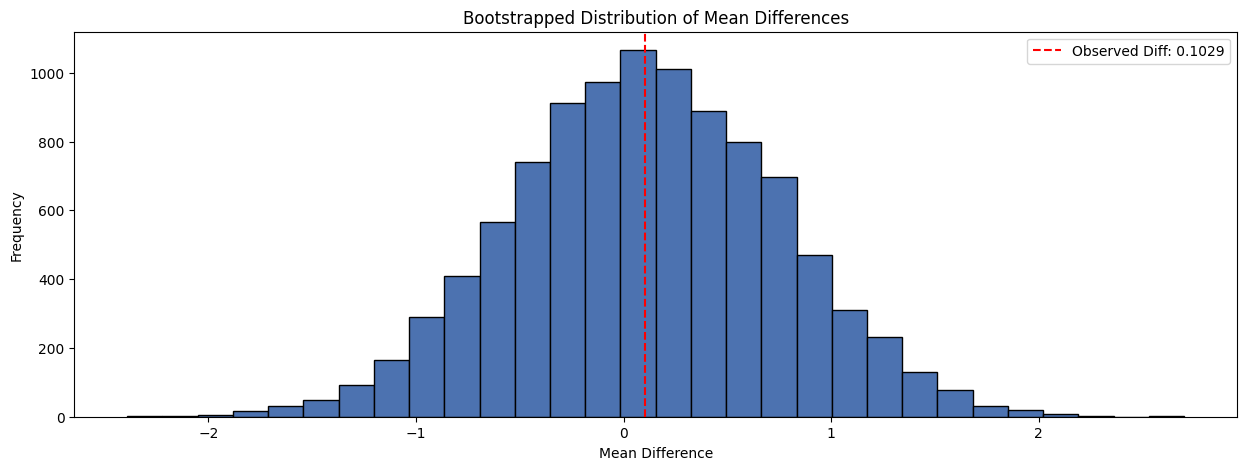

In [ ]:
np.random.seed(12345)

groupvals = sorted(data["version"].unique())
group1 = data.loc[data["version"] == groupvals[0], "sum_gamerounds"].values
group2 = data.loc[data["version"] == groupvals[1], "sum_gamerounds"].values
observed_diff = group1.mean() - group2.mean()

# Permutation test function
def permutation_test(group1_vals, group2_vals, n_permutations=10000):
    combined = np.concatenate([group1_vals, group2_vals])
    n1 = len(group1_vals)
    perm_diffs = []
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_diffs.append(combined[:n1].mean() - combined[n1:].mean())
    
    return np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

# Bootstrap confidence interval function
def bootstrap_ci(group1_vals, group2_vals, n_bootstrap=10000, confidence_level=0.95):
    n1, n2 = len(group1_vals), len(group2_vals)

    bootstrap_diffs = [
            np.random.choice(group1_vals, size=n1, replace=True).mean()
            - np.random.choice(group2_vals, size=n2, replace=True).mean()
            for _ in range(n_bootstrap)
        ]
    lower = np.percentile(bootstrap_diffs, (1 - confidence_level) / 2 * 100)
    upper = np.percentile(bootstrap_diffs, (1 + confidence_level) / 2 * 100)
    return lower, upper, bootstrap_diffs

p_value = permutation_test(group1, group2)
ci_lower, ci_upper, bootstrap_diffs = bootstrap_ci(group1, group2)

print(f"Observed difference: {observed_diff:.4f}")
print(f"Confidence interval: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"P-value: {p_value}")

# Plot bootstrap distribution of mean differences
fig, ax = plt.subplots(figsize=(15, 5))
ax.hist(bootstrap_diffs, bins=30, color="#4C72B0", edgecolor="black")
plt.axvline(observed_diff, color='red', linestyle='--', label=f'Observed Diff: {observed_diff:.4f}')
plt.title("Bootstrapped Distribution of Mean Differences")
plt.xlabel("Mean Difference")
plt.ylabel("Frequency")
plt.legend()
plt.show()

A standard z-test is not reliable for sum_gamerounds because of its heavy right skew (the normality assumption would be violated). Instead, a permutation test is used to access significance by checking how often a random shuffling of the gorup labels produces a difference as large as the observed one. Additionally, bootstrapping is used to estimate a 95% confidence interval around the mean difference.

Both testss confirm what the analysis suggested: the difference between gate_30 and gate_40 in game rounds is not statistically significant as the confidence interval contains 0. The gate placement has not detectable effect on engagement volume. 

## 4. Conclusions
**Retention-focused approach**: The evidence suggests keeping the gate at level 30. 7-day retention is significantly higher for gate_30, suggesting that earlier forced pause prevents burnout and keeps players coming back. The guardrail metric, game rounds, is unaffected by the gate placement, so the improvement in retention does not come at a cost to engagement volume. 

**Monetization-focused approach**: Gate placement has no significant effect on game rounds, so neither version results in more playtime or ad revenue. However, since gate_30 yields better long-term retention, this makes it the better choice in this perspective as well because if more players return to the game over time, that translates to more ad revenue. 

**Recommendation**: Continue with gate_30. It wins on the primary metric retention, has not downside on engagement volume and is the better option even under a monetary view.